In [2]:
%pip install yfinance pandas matplotlib

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/130.2 kB ? eta -:--:--
   ------------------ --------------------- 61.4/130.2 kB 1.1 MB/s eta 0:00:01
   ------------------------------- -------- 102.4/130.2 kB 1.2 MB/s eta 0:00:01
   -------------------------------------- 130.2/130.2 kB 960.0 kB/s eta 0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ----- ---------------------------------- 0.2/1.7 MB 4.4 MB/s eta 0:00:01
   ------------ --------------------------- 0.5/1.7 MB 5.5 MB/s eta 0:00:01
   ------------------------ --------------- 1.0/1.7 MB 7.2 MB/s eta 0:00:01
   ---------------------------------------  1.7/1.7 MB 10.6 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 8.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/144.5 kB ? eta -:--:--
   ---------------------------------------- 144.5/144.5 kB 8.4 MB/s

[*********************100%***********************]  1 of 1 completed

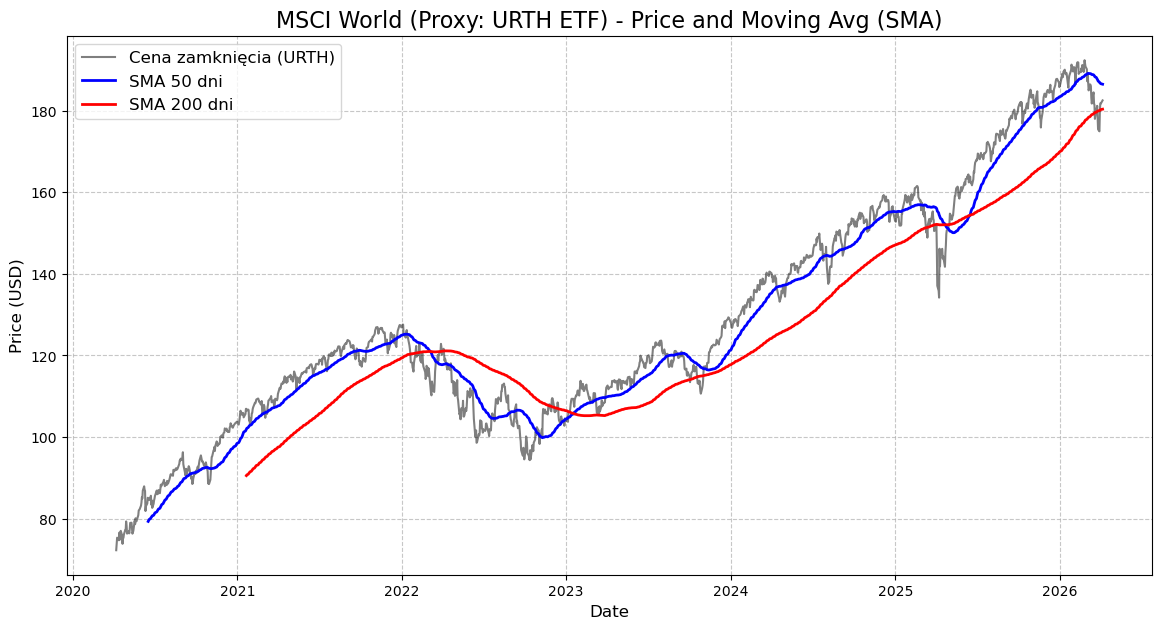

In [7]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

ticker = "URTH"  # Ticker ETF MSCI World
start_date = "2020-04-07"
end_date = "2026-04-07"

print(f"Downloading data {ticker}...")
data = yf.download(ticker, start=start_date, end=end_date)

data['SMA_50'] = data['Close'].rolling(window=50).mean()
data['SMA_200'] = data['Close'].rolling(window=200).mean()

plt.figure(figsize=(14, 7))

# Drawing closing price
plt.plot(data.index, data['Close'], label='Cena zamknięcia (URTH)', color='black', alpha=0.5, linewidth=1.5)

# Drawing SMA line
plt.plot(data.index, data['SMA_50'], label='SMA 50 dni', color='blue', linewidth=2)
plt.plot(data.index, data['SMA_200'], label='SMA 200 dni', color='red', linewidth=2)

plt.title('MSCI World (Proxy: URTH ETF) - Price and Moving Avg (SMA)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

[*********************100%***********************]  1 of 1 completed


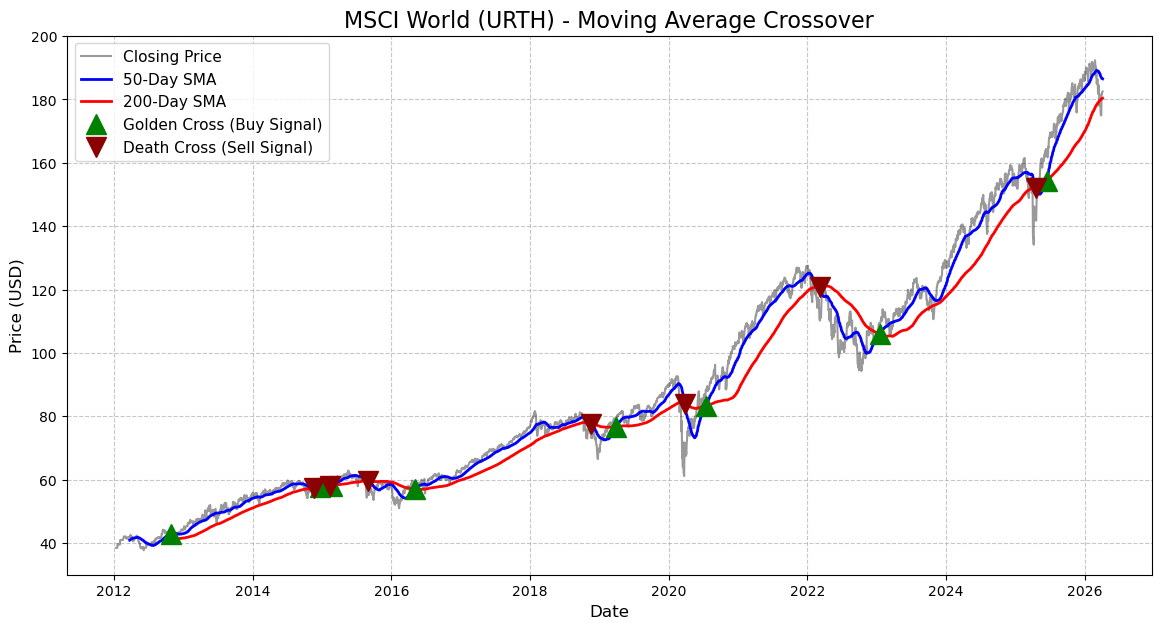

In [10]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

ticker = "URTH"  
start_date = "2010-01-01"
end_date = "2026-04-07" 

data = yf.download(ticker, start=start_date, end=end_date)

data['SMA_50'] = data['Close'].rolling(window=50).mean()
data['SMA_200'] = data['Close'].rolling(window=200).mean()

data['Signal'] = (data['SMA_50'] > data['SMA_200']).astype(int)
data['Position'] = data['Signal'].diff()

plt.figure(figsize=(14, 7))

plt.plot(data.index, data['Close'], label='Closing Price', color='black', alpha=0.4, linewidth=1.5)
plt.plot(data.index, data['SMA_50'], label='50-Day SMA', color='blue', linewidth=2)
plt.plot(data.index, data['SMA_200'], label='200-Day SMA', color='red', linewidth=2)

plt.plot(data[data['Position'] == 1].index, 
         data['SMA_50'][data['Position'] == 1], 
         '^', markersize=15, color='green', label='Golden Cross (Buy Signal)')

plt.plot(data[data['Position'] == -1].index, 
         data['SMA_50'][data['Position'] == -1], 
         'v', markersize=15, color='darkred', label='Death Cross (Sell Signal)')

plt.title('MSCI World (URTH) - Moving Average Crossover', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()